# Spotify Music Recommendation System

## 1\. Objective

The goal of this project is to develop a music recommendation system using Spotify track data, audio features, lyrics\-derived features, and low\-level audio descriptors\. The current focus is on exploratory data analysis \(EDA\), understanding dataset quality, and developing an initial baseline recommendation prototype\.

## 2\. Overview

In [1]:
import pandas as pd

tracks = pd.read_csv("data/SpotGenTrack/Data Sources/spotify_tracks.csv")
artists = pd.read_csv("data/SpotGenTrack/Data Sources/spotify_artists.csv")
albums = pd.read_csv("data/SpotGenTrack/Data Sources/spotify_albums.csv")
audio = pd.read_csv("data/SpotGenTrack/Features Extracted/low_level_audio_features.csv")
lyrics = pd.read_csv("data/SpotGenTrack/Features Extracted/lyrics_features.csv")

In [2]:
import numpy as np

dataset_summary = pd.DataFrame({
    "Dataset": [
        "Tracks",
        "Artists",
        "Albums",
        "Audio Features",
        "Lyrics Features"
    ],
    
    "Rows": [
        len(tracks),
        len(artists),
        len(albums),
        len(audio),
        len(lyrics)
    ],
    
    "Columns": [
        tracks.shape[1],
        artists.shape[1],
        albums.shape[1],
        audio.shape[1],
        lyrics.shape[1]
    ]
})

dataset_summary

,Dataset,Rows,Columns
0,Tracks,101939,32
1,Artists,56129,9
2,Albums,75511,16
3,Audio Features,101909,209
4,Lyrics Features,94954,8


The project combines multiple Spotify\-related datasets containing track metadata, audio features, album information, artist information, and lyric\-derived characteristics\. The datasets together provide a strong foundation for building a content\-based recommendation system\.

## 3\. Data Quality Summary

In [3]:
quality_summary = pd.DataFrame({
    "Check": [
        "Duplicate Rows",
        "Duplicate IDs",
        "Missing Values",
        "Placeholder Values (-1)"
    ],
    
    "Result": [
        "None detected",
        "None detected",
        "Minimal missing values",
        "Present mainly in lyrics dataset"
    ]
})

quality_summary

,Check,Result
0,Duplicate Rows,None detected
1,Duplicate IDs,None detected
2,Missing Values,Minimal missing values
3,Placeholder Values (-1),Present mainly in lyrics dataset


Overall dataset quality was found to be strong\. Most datasets contained no duplicate rows, no duplicate identifiers, and only minimal missing values\. Placeholder values \(\-1\) were primarily observed in lyric\-related features and likely represent unavailable or failed lyric extraction\.

## 4\. Main EDA Findings

### 4\.1 Feature Distribution Dashboard

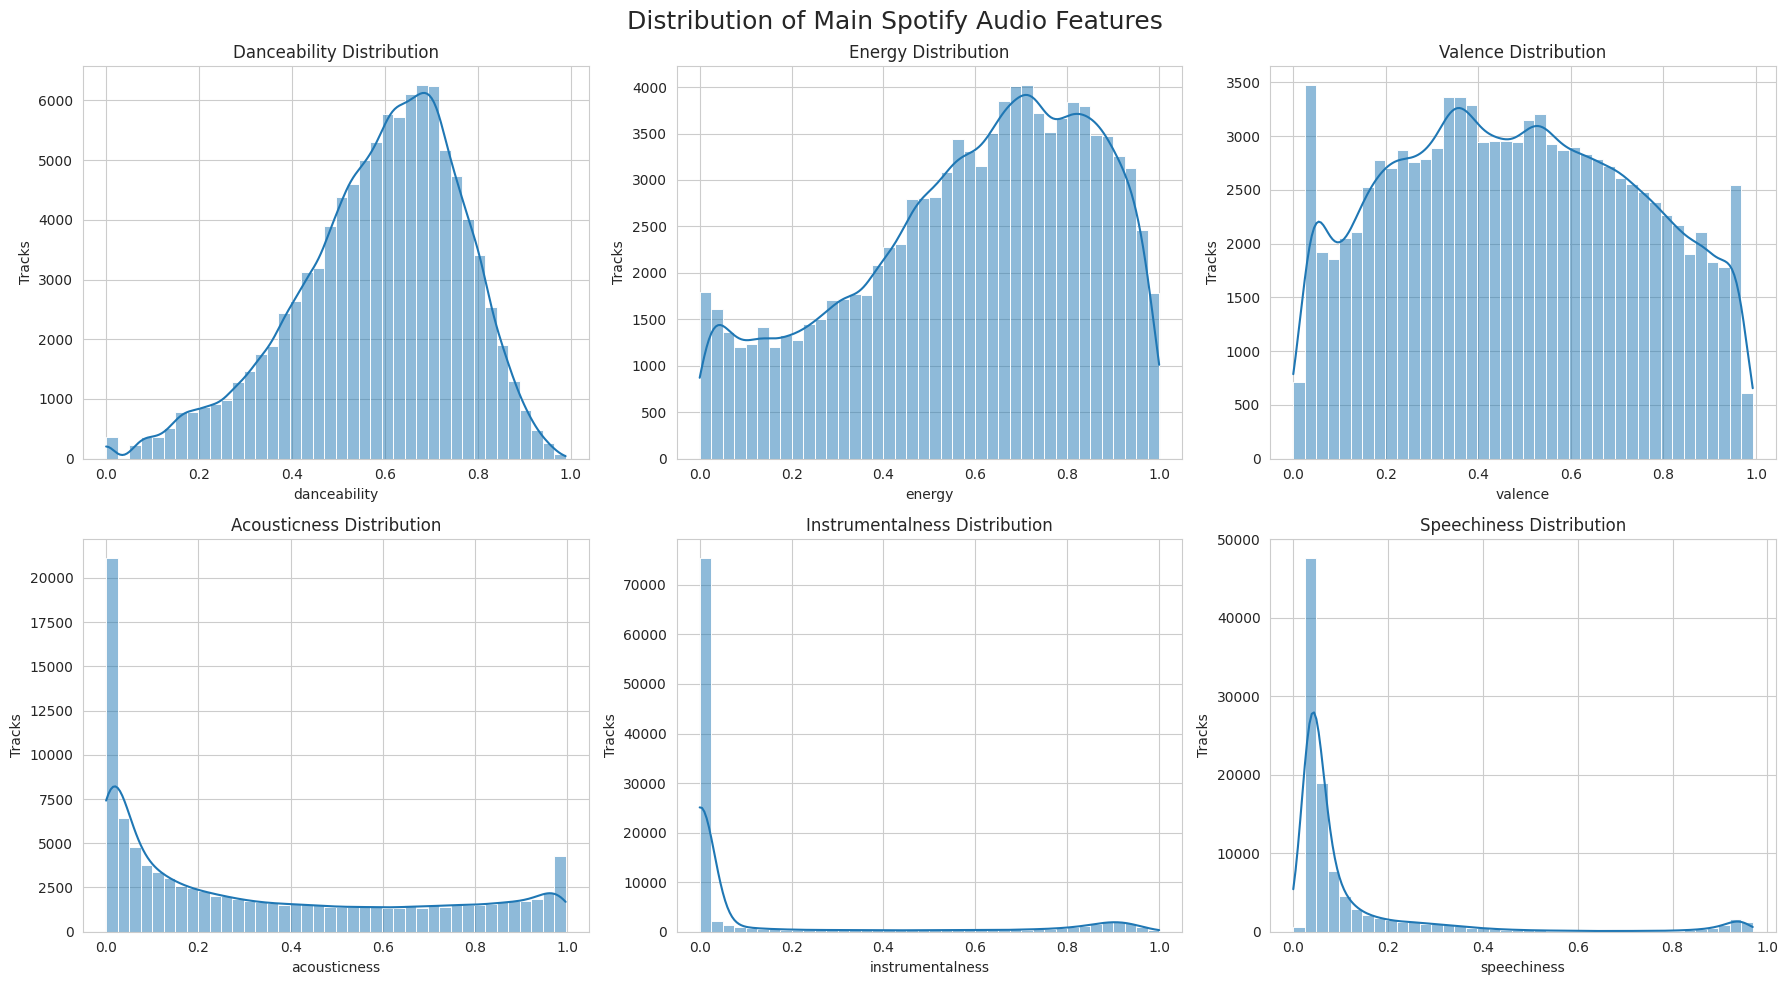

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(
        tracks[feature],
        bins=40,
        kde=True,
        ax=ax
    )
    
    ax.set_title(f"{feature.capitalize()} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Tracks")

plt.suptitle("Distribution of Main Spotify Audio Features", fontsize=18)
plt.tight_layout()
plt.show()

### 4\.2 Popularity Distribution

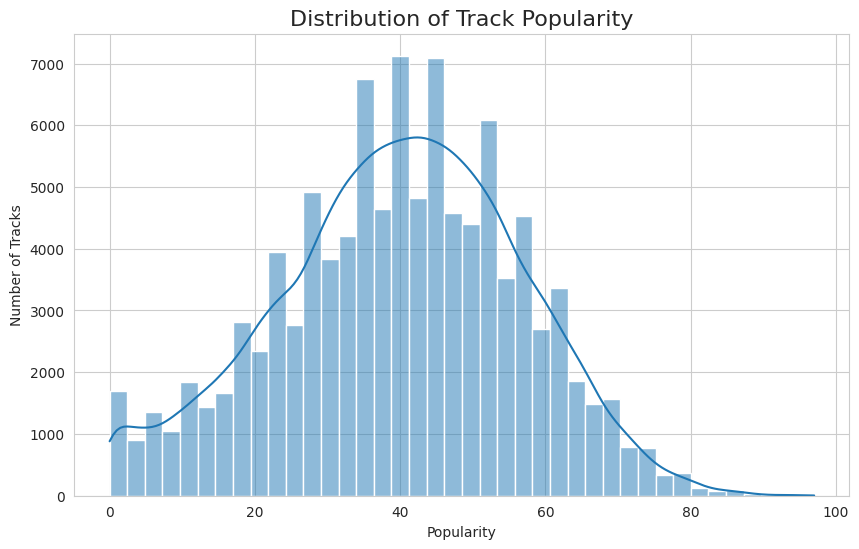

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    tracks["popularity"],
    bins=40,
    kde=True
)

plt.title("Distribution of Track Popularity", fontsize=16)
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")

plt.show()

### 4\.3 Popularity vs Danceability

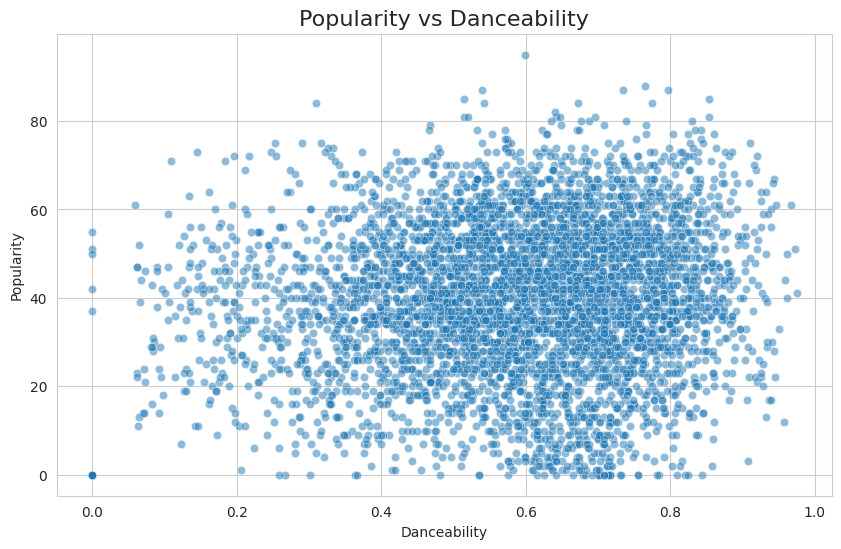

In [7]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tracks.sample(5000, random_state=42),
    x="danceability",
    y="popularity",
    alpha=0.5
)

plt.title("Popularity vs Danceability", fontsize=16)
plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.show()

## 5\. Correlation Heatmap

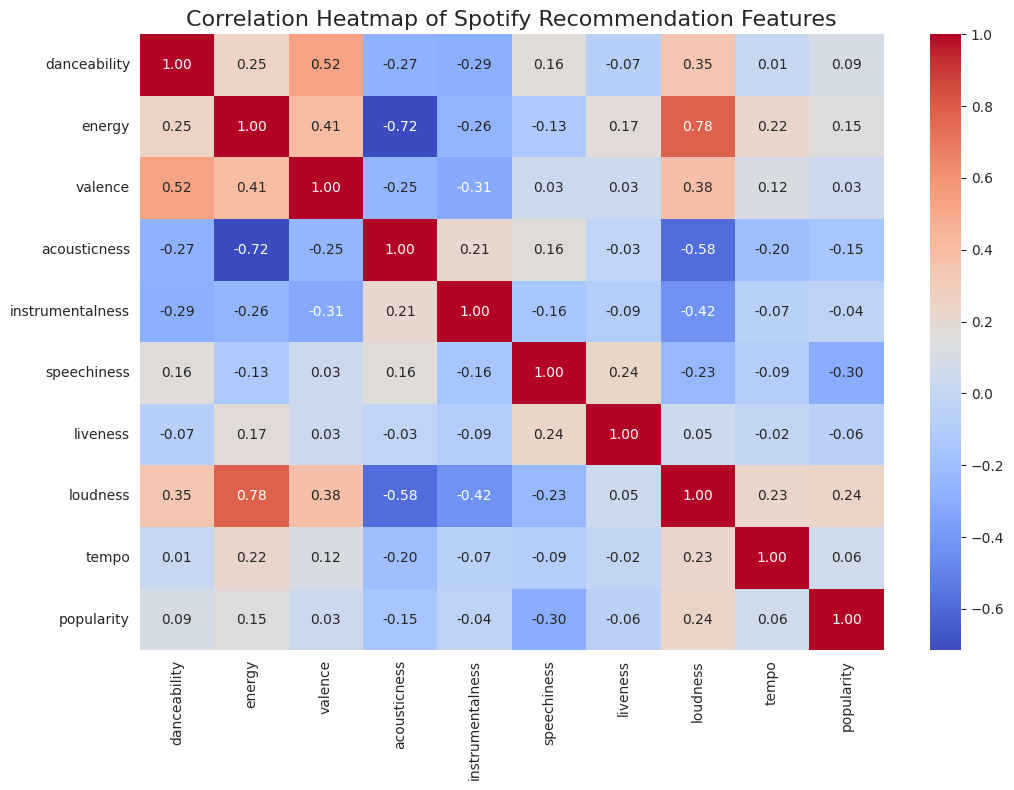

In [19]:
correlation_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "loudness",
    "tempo",
    "popularity"
]

correlation_matrix = tracks[correlation_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap of Spotify Recommendation Features",
    fontsize=16
)

plt.show()

## 6\. Genre Distribution  

In [21]:
tracks.columns

Index(['Unnamed: 0', 'acousticness', 'album_id', 'analysis_url', 'artists_id',
       'available_markets', 'country', 'danceability', 'disc_number',
       'duration_ms', 'energy', 'href', 'id', 'instrumentalness', 'key',
       'liveness', 'loudness', 'lyrics', 'mode', 'name', 'playlist',
       'popularity', 'preview_url', 'speechiness', 'tempo', 'time_signature',
       'track_href', 'track_name_prev', 'track_number', 'uri', 'valence',
       'type'],
      dtype='object')

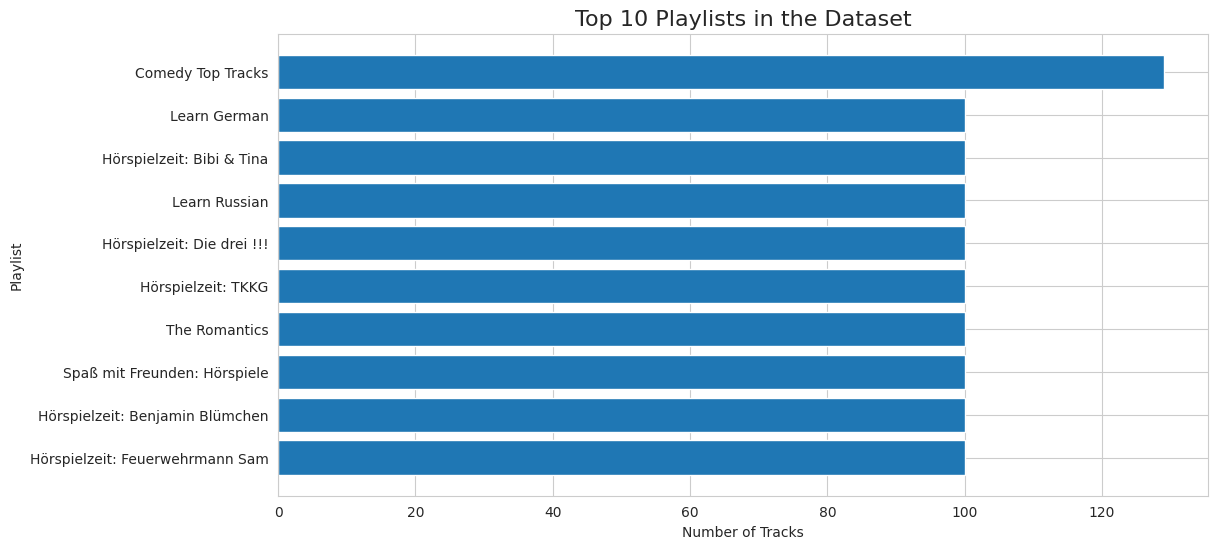

In [29]:
top_playlists = (
    tracks["playlist"]
    .dropna()
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_playlists.index,
    top_playlists.values
)

plt.title("Top 10 Playlists in the Dataset", fontsize=16)
plt.xlabel("Number of Tracks")
plt.ylabel("Playlist")

plt.show()

In [31]:
artists.columns

Index(['Unnamed: 0', 'artist_popularity', 'followers', 'genres', 'id', 'name',
       'track_id', 'track_name_prev', 'type'],
      dtype='object')

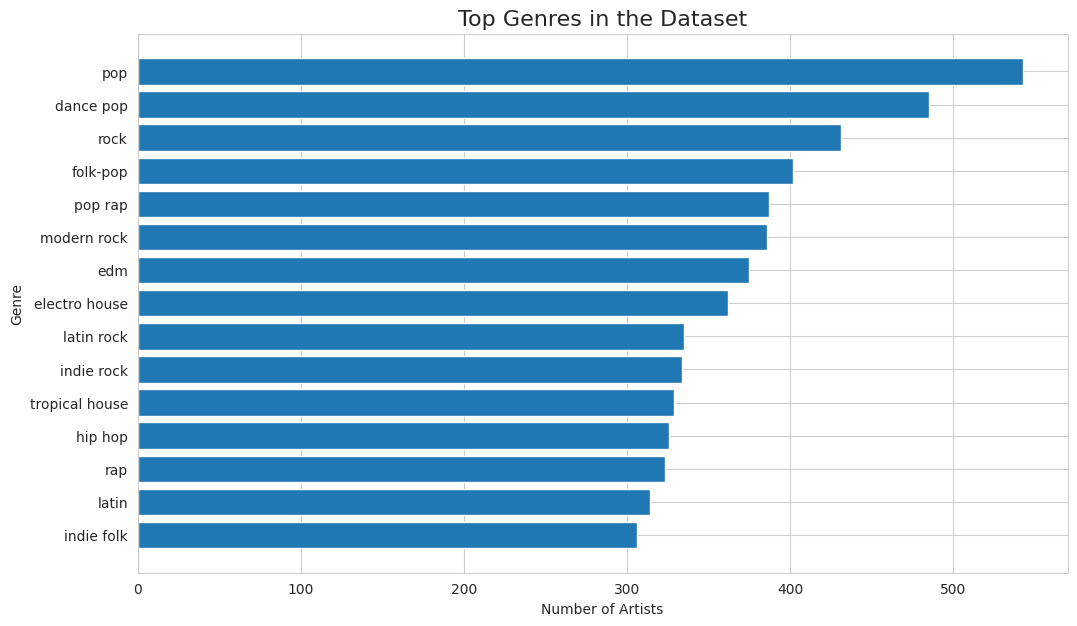

In [41]:
import ast

# Convert string lists into actual Python lists
artists["genres_parsed"] = artists["genres"].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else []
)

# Explode genres into separate rows
genre_counts = (
    artists["genres_parsed"]
    .explode()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 7))

plt.barh(
    genre_counts.index,
    genre_counts.values
)

plt.title("Top Genres in the Dataset", fontsize=16)
plt.xlabel("Number of Artists")
plt.ylabel("Genre")

plt.show()

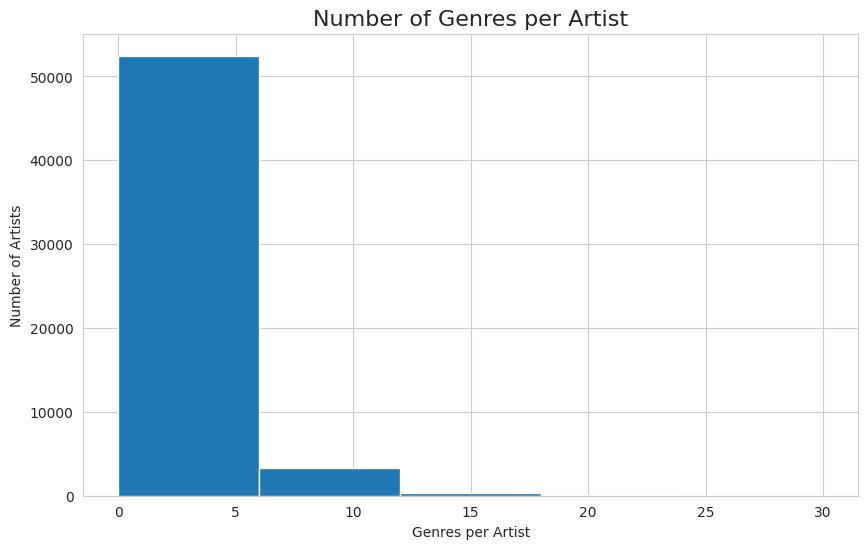

In [49]:
artists["genre_count"] = artists["genres_parsed"].apply(len)

plt.figure(figsize=(10, 6))

plt.hist(
    artists["genre_count"],
    bins=5
)

plt.title("Number of Genres per Artist", fontsize=16)
plt.xlabel("Genres per Artist")
plt.ylabel("Number of Artists")

plt.show()

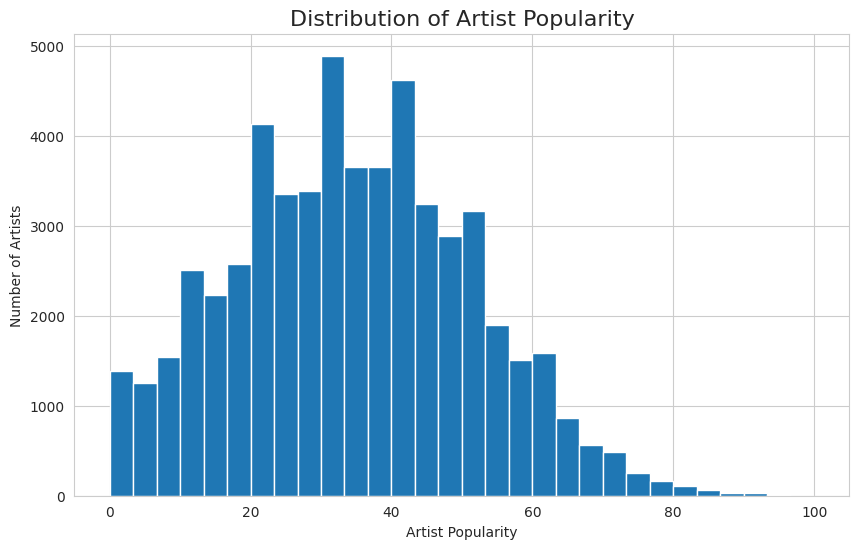

In [51]:
plt.figure(figsize=(10, 6))

plt.hist(
    artists["artist_popularity"],
    bins=30
)

plt.title("Distribution of Artist Popularity", fontsize=16)
plt.xlabel("Artist Popularity")
plt.ylabel("Number of Artists")

plt.show()

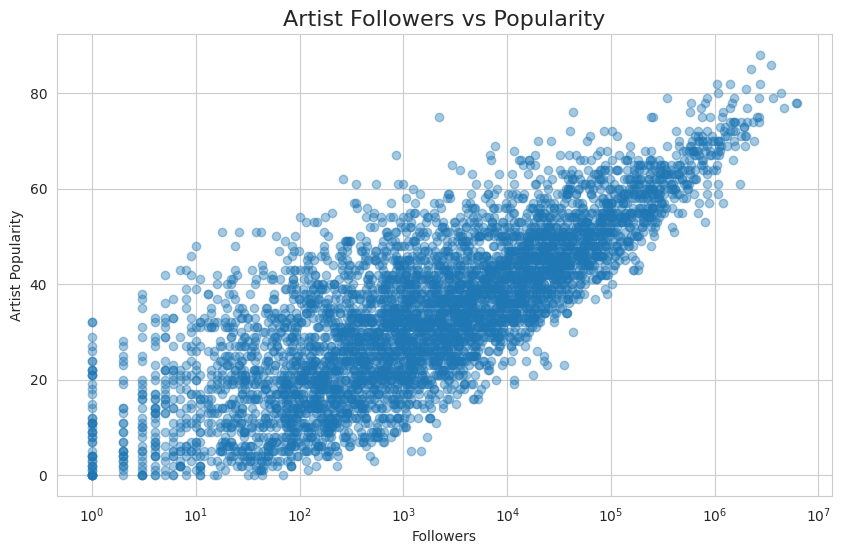

In [53]:
artist_sample = artists.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(
    artist_sample["followers"],
    artist_sample["artist_popularity"],
    alpha=0.4
)

plt.title("Artist Followers vs Popularity", fontsize=16)
plt.xlabel("Followers")
plt.ylabel("Artist Popularity")

plt.xscale("log")

plt.show()

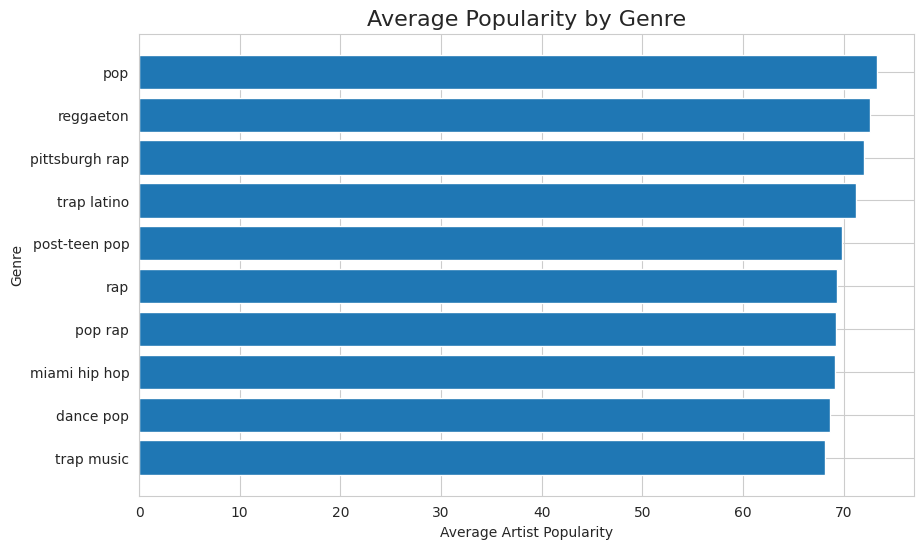

In [55]:
genre_popularity = (
    artists.explode("genres_parsed")
    .groupby("genres_parsed")["artist_popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    genre_popularity.index,
    genre_popularity.values
)

plt.title("Average Popularity by Genre", fontsize=16)
plt.xlabel("Average Artist Popularity")
plt.ylabel("Genre")

plt.show()

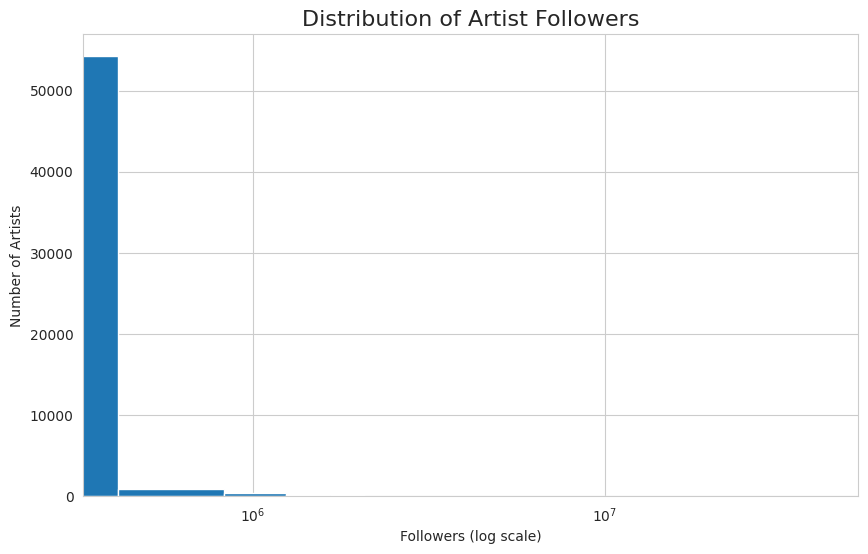

In [61]:
plt.figure(figsize=(10, 6))

plt.hist(
    artists["followers"],
    bins=100
)

plt.xscale("log")

plt.title("Distribution of Artist Followers", fontsize=16)
plt.xlabel("Followers (log scale)")
plt.ylabel("Number of Artists")

plt.show()

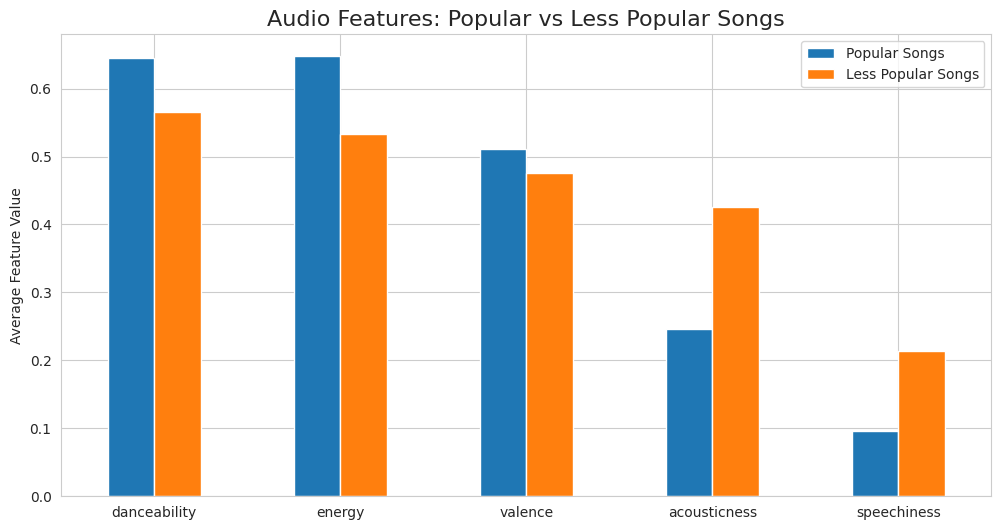

In [33]:
popular_tracks = tracks[tracks["popularity"] >= 70]
less_popular_tracks = tracks[tracks["popularity"] <= 30]

features_compare = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness"
]

comparison_df = pd.DataFrame({
    "Popular Songs": popular_tracks[features_compare].mean(),
    "Less Popular Songs": less_popular_tracks[features_compare].mean()
})

comparison_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Audio Features: Popular vs Less Popular Songs", fontsize=16)
plt.ylabel("Average Feature Value")
plt.xticks(rotation=0)

plt.show()

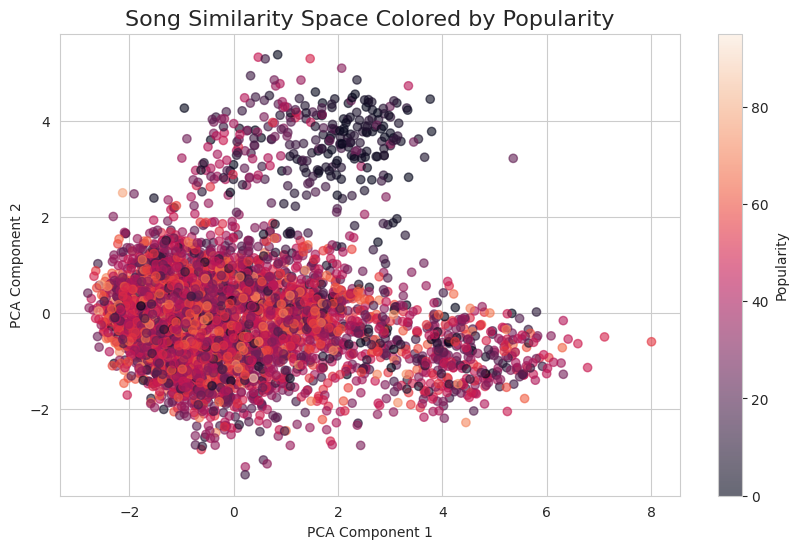

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_result = pca.fit_transform(tracks_scaled)

pca_df = pd.DataFrame({
    "PCA1": pca_result[:, 0],
    "PCA2": pca_result[:, 1],
    "popularity": tracks["popularity"]
})

sample_df = pca_df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    sample_df["PCA1"],
    sample_df["PCA2"],
    c=sample_df["popularity"],
    alpha=0.6
)

plt.colorbar(scatter, label="Popularity")

plt.title("Song Similarity Space Colored by Popularity", fontsize=16)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

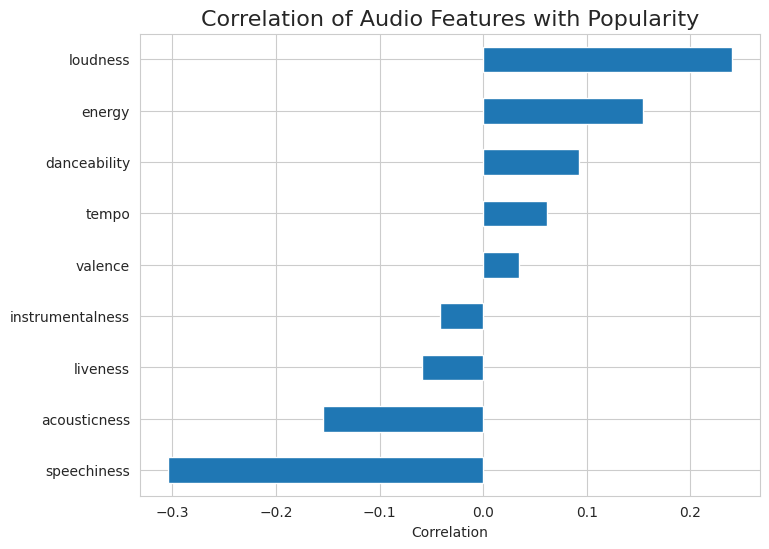

In [37]:
popularity_corr = (
    tracks[
        [
            "danceability",
            "energy",
            "valence",
            "acousticness",
            "instrumentalness",
            "speechiness",
            "liveness",
            "loudness",
            "tempo",
            "popularity"
        ]
    ]
    .corr()["popularity"]
    .sort_values()
)

plt.figure(figsize=(8, 6))

popularity_corr.drop("popularity").plot(
    kind="barh"
)

plt.title("Correlation of Audio Features with Popularity", fontsize=16)
plt.xlabel("Correlation")

plt.show()

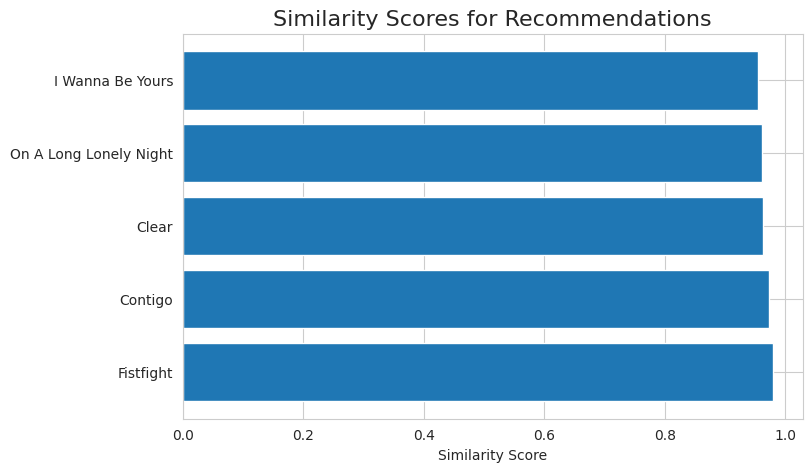

In [39]:
sample_track = tracks.iloc[0]["name"]

recommendations = recommend_tracks_knn(sample_track)

plt.figure(figsize=(8, 5))

plt.barh(
    recommendations["name"],
    recommendations["similarity"]
)

plt.title(f"Similarity Scores for Recommendations", fontsize=16)
plt.xlabel("Similarity Score")

plt.show()

## 7. Recommendation Pipeline

| Step | Description |
|---|---|
| 1. Data Input | Spotify tracks, audio features, lyrics, artists, albums |
| 2. Feature Selection | Select audio features such as danceability, energy, valence, tempo |
| 3. Standardization | Scale features so no variable dominates |
| 4. Similarity Space | Represent each song as a numerical feature vector |
| 5. KNN Search | Find the nearest songs using cosine distance |
| 6. Recommendation Output | Return the most similar tracks |

## Main exploratory findings include:

- Most tracks exhibit medium-to-high danceability and energy.
- Strong relationships exist between certain audio features, such as energy and loudness.
- Popularity is not strongly determined by a single audio characteristic.
- Audio features alone capture technical similarity, but may not fully represent perceived musical similarity.
- The datasets appear sufficiently clean and suitable for recommendation modeling.

## Recommendation Approaches Considered

Several recommendation approaches were considered during the development of the Spotify recommendation system. Since the current project phase (Py3) focuses primarily on exploratory analysis, model reasoning, and architectural planning, the goal was to identify suitable recommendation strategies and evaluate their advantages, limitations, and scalability for large music datasets.

| Approach | Description | Advantages | Limitations | Current Status |
|---|---|---|---|---|
| Content-Based Filtering | Recommends songs based on similarity between audio features such as danceability, energy, tempo, and valence. | Simple, interpretable, no user history required. | May overspecialize recommendations and ignore broader context. | Baseline concept |
| Cosine Similarity Matrix | Computes pairwise similarity between all tracks using cosine similarity. | Intuitive similarity calculation. | Computationally expensive and memory intensive for over 100k tracks. | Explored conceptually |
| K-Nearest Neighbors (KNN) | Dynamically finds the nearest tracks using cosine distance in feature space. | More scalable than storing a full similarity matrix. | Recommendation quality depends strongly on selected features. | Implemented baseline |
| Clustering (e.g. K-Means) | Groups similar songs into clusters representing moods, genres, or listening profiles. | Useful for playlist generation and music grouping. | Cluster quality depends on feature engineering and parameter tuning. | Planned |
| Hybrid Recommendation System | Combines multiple recommendation approaches and metadata sources such as genres, lyrics, popularity, and audio descriptors. | Potentially richer and more context-aware recommendations. | Higher preprocessing complexity and scalability challenges. | Future work |

Among the considered approaches, K-Nearest Neighbors (KNN) was selected as the initial baseline recommender because it scales better than a full cosine similarity matrix while still supporting similarity-based recommendations using Spotify audio features. A full pairwise similarity matrix became computationally expensive for over 100,000 tracks in the available Deepnote environment, making KNN a more practical solution for the interim prototype.

## Baseline Recommender

For the interim prototype, a baseline content-based recommender was built using K-Nearest Neighbors (KNN). The recommender uses standardized Spotify audio features such as danceability, energy, valence, acousticness, instrumentalness, speechiness, liveness, loudness, and tempo.

A full cosine similarity matrix was not used because the dataset contains over 100,000 tracks. Computing pairwise similarities for all tracks would require a very large matrix and exceed the available memory in the Deepnote environment. KNN was therefore selected as a more scalable baseline approach, because it finds the closest tracks dynamically without storing all pairwise similarities.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Features used for the baseline recommender
recommendation_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "loudness",
    "tempo"
]

# Scale features so that tempo/loudness do not dominate smaller 0-1 features
scaler = StandardScaler()
tracks_scaled = scaler.fit_transform(tracks[recommendation_features])

# Fit KNN model using cosine distance
knn_model = NearestNeighbors(
    n_neighbors=6,
    metric="cosine",
    algorithm="brute"
)

knn_model.fit(tracks_scaled)

print("Baseline KNN recommender is ready.")

Baseline KNN recommender is ready.


In [9]:
def recommend_tracks_knn(track_name, top_n=5):
    matches = tracks[tracks["name"].str.lower() == track_name.lower()]
    
    if matches.empty:
        return f"Track '{track_name}' not found."
    
    track_idx = matches.index[0]
    track_vector = tracks_scaled[track_idx].reshape(1, -1)
    
    distances, indices = knn_model.kneighbors(
        track_vector,
        n_neighbors=top_n + 1
    )
    
    recommended_indices = indices[0][1:]
    
    recommendations = tracks.iloc[recommended_indices][
        ["name", "popularity", "danceability", "energy", "valence", "tempo"]
    ].copy()
    
    recommendations["similarity"] = 1 - distances[0][1:]
    
    return recommendations

In [25]:
## Example Recommender

recommendations = recommend_tracks_knn("Billie Jean")

recommendations_clean = recommendations[
    ["name", "popularity", "danceability", "energy", "valence", "tempo", "similarity"]
].copy()

recommendations_clean["similarity"] = recommendations_clean["similarity"].round(3)
recommendations_clean

,name,popularity,danceability,energy,valence,tempo,similarity
101367,Billie Jean,84.0,0.920,0.654,0.847,117.046,1.000
97241,Para Enamorarte,64.0,0.817,0.676,0.796,115.999,0.990
81305,Desde o Início - Beowülf Remix,32.0,0.871,0.647,0.821,124.017,0.990
9748,Who's Up?,43.0,0.915,0.622,0.856,118.076,0.990
101835,Checklist (with Calvin Harris) (feat. WizKid),64.0,0.890,0.624,0.762,116.046,0.989


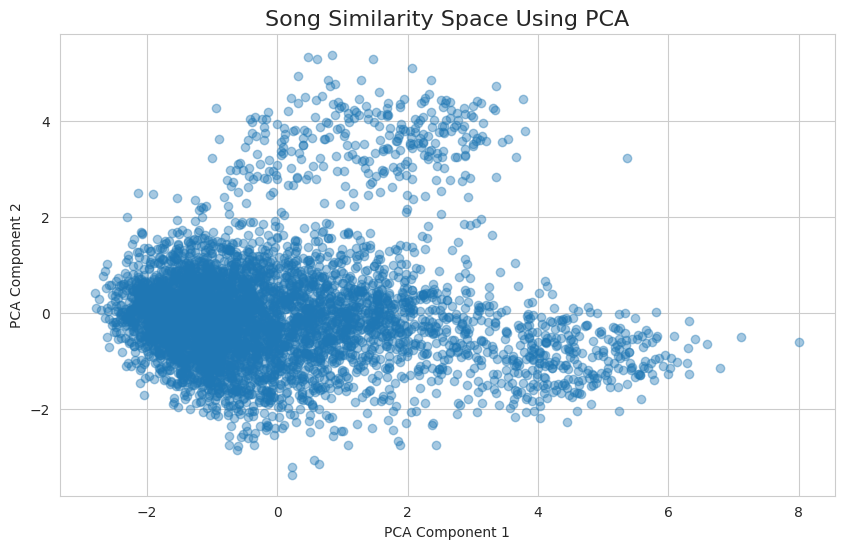

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Use the same scaled features from the KNN model
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tracks_scaled)

pca_df = pd.DataFrame({
    "PCA 1": pca_result[:, 0],
    "PCA 2": pca_result[:, 1],
    "name": tracks["name"],
    "popularity": tracks["popularity"]
})

# Sample for readability
pca_sample = pca_df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(
    pca_sample["PCA 1"],
    pca_sample["PCA 2"],
    alpha=0.4
)

plt.title("Song Similarity Space Using PCA", fontsize=16)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## Key EDA Findings

- Most tracks show medium-to-high danceability and energy.
- Energy and loudness are strongly related.
- Popularity is not explained by one single audio feature.
- Audio features are useful for technical similarity.
- Human musical taste needs more context than audio features alone.

## Scalability and Technical Limitation

- Dataset contains over 100,000 tracks.
- A full cosine similarity matrix would require comparing every track with every other track.
- This results in extremely high memory usage and poor scalability.
- The Deepnote environment could not handle the full similarity matrix computation.
- A K-Nearest Neighbors (KNN) approach was therefore selected instead.
- KNN retrieves nearest tracks dynamically rather than storing all pairwise similarities.
- This makes the baseline recommender more scalable and computationally practical.
- The current implementation serves as an initial prototype for future recommendation improvements.

## Current Limitations

The current baseline recommendation system has several limitations that should be considered:

- Recommendations are currently based only on Spotify audio features.
- Genre and artist relationships are not yet integrated into the recommendation process.
- Lyrics-derived features still require additional preprocessing and handling of placeholder values.
- Low-level audio descriptors have not yet been incorporated into the model.
- Recommendation quality is currently evaluated qualitatively rather than through user feedback or interaction data.
- Pure audio-feature similarity does not always correspond to perceived musical similarity by listeners.
- Scalability remains an important consideration for larger recommendation systems and more advanced models.

## Next Steps

- Integrate genre and artist information.
- Add lyric-based similarity.
- Use clustering for playlist or mood discovery.
- Test dimensionality reduction with PCA.
- Compare recommendation strategies.
- Move toward a hybrid recommender system.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f51f68fc-16af-4ff9-b4f3-009bd2125c28' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>